## STEP 1: Exploratory Data Analysis:


### Import libraries:

In [1]:
import os
import pandas as pd
import numpy as np 

import json
import cv2
import matplotlib as plt

from PIL import Image

### Load data

In [2]:
print(os.listdir("../data"))

splits = ["train","val","test"]
    

['instances_test2019.json', 'instances_train2019.json', 'instances_val2019.json', 'test2019', 'train2019', 'val2019']


In [3]:
import os

splits = ["train", "val", "test"]
data_root = "../data"
data_map = {}

for split in splits:
    #sub-dictionary for every split
    data_map[split] = {
        "images": os.path.join(data_root, f"{split}2019"),
        "annotations": os.path.join(data_root, f"instances_{split}2019.json")
    }

# --- Verification Loop ---
for split, info in data_map.items():
    print("-" * 30)
    print(f"Checking Split: {split.upper()}")
    
    img_dir = info["images"]
    ann_file = info["annotations"]

    if os.path.exists(img_dir) and os.path.exists(ann_file):
        num_files = len(os.listdir(img_dir))
        print(f"  [OK] Images Path: {img_dir} ({num_files} files found)")
        print(f"  [OK] JSON Path:   {ann_file}")
    else:
        print(f"  [ERROR] Path mismatch for {split}!")
    print()

------------------------------
Checking Split: TRAIN
  [OK] Images Path: ../data\train2019 (53739 files found)
  [OK] JSON Path:   ../data\instances_train2019.json

------------------------------
Checking Split: VAL
  [OK] Images Path: ../data\val2019 (6000 files found)
  [OK] JSON Path:   ../data\instances_val2019.json

------------------------------
Checking Split: TEST
  [OK] Images Path: ../data\test2019 (24000 files found)
  [OK] JSON Path:   ../data\instances_test2019.json



In [4]:
#Unpack the paths and store them in clear variables for later use:

train_img = data_map["train"]["images"]
train_json = data_map["train"]["annotations"]

val_img = data_map["val"]["images"]
val_json = data_map["val"]["annotations"]

test_img = data_map['test']['images']
test_json = data_map['test']['annotations']

### Explore JSON Files:

In [5]:
#Explore the JSON structure

#Open json file (instance_train.json in this example):
with open(train_json, 'r') as f:
    data = json.load(f)


print(data.keys(), '\n')

if 'images' in data:
    print(f"First Image entries: {data['images'][0]}")
    print()
    
if 'categories' in data:
    print(f"First categories: {data['categories'][0]}")

if 'annotations' in data:   
    print(f"Fisrt annotations entry: {data['annotations'][0]}")


dict_keys(['info', 'licenses', 'categories', '__raw_Chinese_name_df', 'images', 'annotations']) 

First Image entries: {'file_name': '038900004095_camera0-13.jpg', 'width': 2592, 'height': 1944, 'id': 0}

First categories: {'supercategory': 'puffed_food', 'id': 1, 'name': '1_puffed_food'}
Fisrt annotations entry: {'area': 111763.29, 'bbox': [1188.4, 1052.45, 390.96, 285.87], 'category_id': 112, 'id': 0, 'image_id': 0, 'iscrowd': 0, 'segmentation': [[]], 'point_xy': [1383.88, 1195.38]}


In [6]:
#Create a unified dictionary to link each [id] with its corresponding [category]

supercategory_id_to_name = {category['id']:category['supercategory'] for category in data['categories']}
category_id_to_name =  {category['id']:category['name'] for category in data['categories']}

#Confirm the number of categories (should be 200)
print(f"Total number of categories: {len(supercategory_id_to_name)}")
print(f"toatl number of sub_categories: {len(category_id_to_name)}")

print(f"\n Sample category ID: {supercategory_id_to_name.get(8)}")
print(f"Sample category ID: {category_id_to_name.get(8)}")

Total number of categories: 200
toatl number of sub_categories: 200

 Sample category ID: puffed_food
Sample category ID: 8_puffed_food


In [7]:
#pick random images (to not always pick the first one):

import random
sample_img = random.choice(data['images'])
img_id = sample_img['id']
file_name = sample_img['file_name']

#get image annotation:
img_ann = [ann for ann in data['annotations'] if ann['image_id'] == img_id]

#print the random image chosen (you should get a random image everytime)

print(sample_img) 
print(f"Image ID: {img_id}")
print(f"File Name: {file_name}")

print(f"Number of annotations for this image: {len(img_ann)}")

#get the img category / supercategoroy:
#first get the category_id from the annotation (assuming one or more category per image)
for ann in img_ann:
    category_id = ann['category_id']
    img_category = category_id_to_name.get(category_id)
    img_supercategory = supercategory_id_to_name.get(category_id)

    print(f"\nAnnotation ID: {ann['id']}") #should match the Image ID !!
    print(f"Image Supercategory: {img_supercategory}")
    print(f"Image Category: {img_category}")
    


{'file_name': '6941543400251_camera3-18.jpg', 'width': 2592, 'height': 1944, 'id': 36116}
Image ID: 36116
File Name: 6941543400251_camera3-18.jpg
Number of annotations for this image: 1

Annotation ID: 36116
Image Supercategory: milk
Image Category: 104_milk


### Disiplay Some Images with their bounding Boxes

--------------------------------------------------
Split: TRAIN
Split Path:                     ../data\train2019
Random image from train split:    6914973603394~A_camera2-38.jpg
Full path to random image:      ../data\train2019\6914973603394~A_camera2-38.jpg
{'file_name': '038900004095_camera0-13.jpg', 'width': 2592, 'height': 1944, 'id': 0}
--------------------------------------------------
Split: VAL
Split Path:                     ../data\val2019
Random image from val split:    20180920-14-46-29-1411.jpg
Full path to random image:      ../data\val2019\20180920-14-46-29-1411.jpg
{'file_name': '20180827-16-07-06-756.jpg', 'width': 1850, 'height': 1850, 'id': 220, 'level': 'easy'}
--------------------------------------------------
Split: TEST
Split Path:                     ../data\test2019
Random image from test split:    20181017-14-10-16-2150.jpg
Full path to random image:      ../data\test2019\20181017-14-10-16-2150.jpg
{'file_name': '20180824-15-44-39-474.jpg', 'width': 1831, 'he

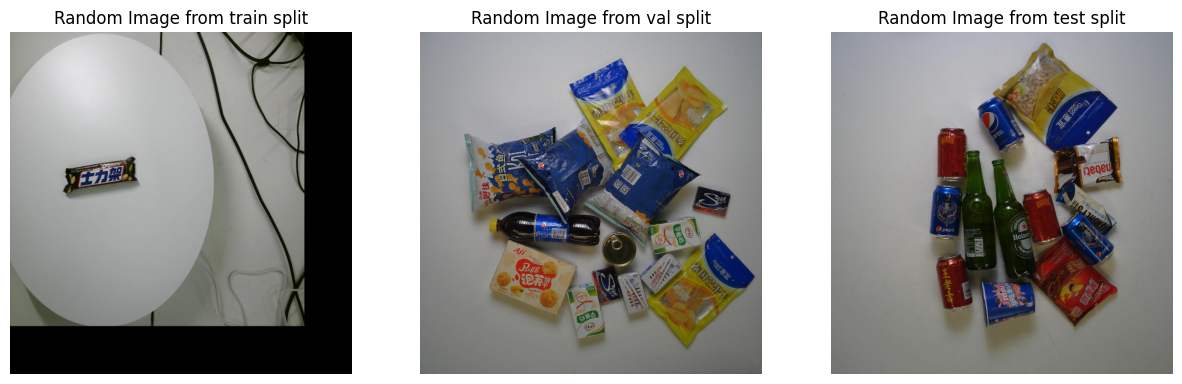

In [8]:
#FIRST TRY: ALL OWRKING EXCPET BOUDNing BOXES
import matplotlib.pyplot as plt
import cv2
import os

#print one image from each split to confirm the paths:

plt.figure(figsize=(15,5))
for i , split in enumerate(splits):
    img_dir = data_map[split]["images"]
    random_img_name = random.choice(os.listdir(img_dir))

    #print the full path:    
    print("-" * 50)
    print(f"Split: {split.upper()}")
    print(f"Split Path:                     {img_dir}")
    print(f"Random image from {split} split:    {random_img_name}")
    print(f"Full path to random image:      {os.path.join(img_dir, random_img_name)}")

    #open the image using cv2:
    img_path = os.path.join(img_dir,random_img_name)
    img = cv2.imread(img_path)

    #convert the image to RGB for displaying:
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(rgb_img, (640,640)) #resize the image to 640x640 for better visualization


    #draw the bounding boxes on the image using the annotation file:
    with open(data_map[split]["annotations"], 'r') as f:
        data = json.load(f)

        print(data['images'][0])
       
        

    #display the image using matplotlib:
    #plot all the images next to each other using subplots:
    plt.subplot(1,3,i+1)
    
    plt.imshow(img_resized)
    plt.title(f"Random Image from {split} split")
    plt.axis('off')
    

plt.show()

--------------------------------------------------
Split: TRAIN
Split Path:              ../data\train2019
file_name:              6953631801604-back_camera2-15.jpg
full path               ../data\train2019\6953631801604-back_camera2-15.jpg
Number of annotations for this image: 1
--------------------------------------------------
Split: VAL
Split Path:              ../data\val2019
file_name:              20180911-16-33-15-261.jpg
full path               ../data\val2019\20180911-16-33-15-261.jpg
Number of annotations for this image: 17
--------------------------------------------------
Split: TEST
Split Path:              ../data\test2019
file_name:              20180911-15-27-45-132.jpg
full path               ../data\test2019\20180911-15-27-45-132.jpg
Number of annotations for this image: 19


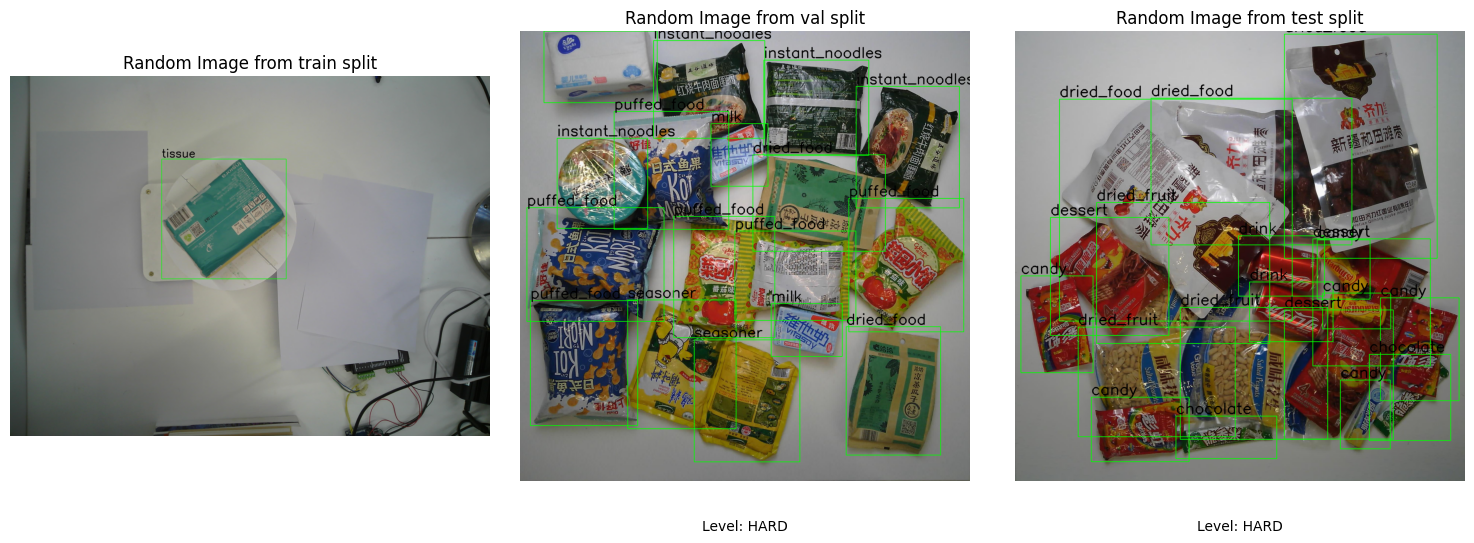

In [9]:
import matplotlib.pyplot as plt
import cv2
import os
import random

#print one image from each split to confirm the paths:

plt.figure(figsize=(15,5))
for i , split in enumerate(splits):
        #Define the paths for the current split (train, val, or test)
        ann_path = data_map[split]["annotations"]
        img_dir = data_map[split]["images"]

        print("-" * 50)
        print(f"Split: {split.upper()}")
        print(f"Split Path:              {img_dir}")

        #open the annotation file and get the image name + bounding boxes
        with open(ann_path, 'r') as f:
                data = json.load(f)
        
        #pick a random image from the current split:
        random_img = random.choice(data['images'])
        img_id = random_img['id']
        file_name = random_img['file_name']
        print(f"file_name:              {file_name}")
        print(f"full path               {os.path.join(img_dir, file_name)}")

        #get the annotations for that specific image:
        img_ann = [ann for ann in data['annotations'] if ann['image_id'] == img_id]

        #print(f"\nimage annotations for image ID {img_id}: {img_ann}")
        print(f"Number of annotations for this image: {len(img_ann)}")

        #load the image using cv2:
        img_path = os.path.join(img_dir , file_name)
        img = cv2.imread(img_path)
        #convert the image to RGB:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


        #draw the bounding boxes over the image (with their unique categories):
        unique_categories = set()
        for ann in img_ann:
                #get the category name:
                categoroy_id = ann['category_id']
                # category_name = category_id_to_name.get(categoroy_id) 
                supercategory_name = supercategory_id_to_name.get(categoroy_id)
                unique_categories.add(supercategory_name)

                #COCO format for bounding box is [x_min, y_min, width, height]
                bbox = ann['bbox'] #get the coordinates

                x , y , w , h = bbox

                #draw the box using cv2.rectangle (image, start_point, end_point, color, thickness)
                cv2.rectangle(img, ( int(x), int(y) ), ( int(x+w),int(y+h) ) , (0,255,0), 2)

                #put the supercategory name above the boudnign box:
                #parameters: (image, text, position, font, font_scale, color, thickness)
                cv2.putText(img, supercategory_name, (int(x), int(y)-10),
                                 cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,0), 3) 
                
                
        #display the image using matplotlib:
        #plot all the images next to each other using subplots:

        plt.subplot(1,3,i+1)
        plt.imshow(img)
        plt.title(f"Random Image from {split} split")
        plt.axis('off')

        #val and test splits have a level (easy , medium or hard) that we can add as a text under the image:
        if split in ['val', 'test']:
               # Use .get() to avoid errors if for some reason the key is missing
                level = random_img.get('level', 'unknown')

                #plt.text parameters: (x, y, text, horizontalalignment, verticalalignment, transform)
                plt.text(0.5,-0.1, f"Level: {level.upper()}", ha = 'center' , va = 'center', transform=plt.gca().transAxes)
plt.tight_layout()
plt.show()

In [10]:
# Final Data Integrity Report (Sanity Check)
print(f"{'Split':<10} | {'Images (Files)':<15} | {'Images (JSON)':<15} | {'Annotations':<15}")
print("-" * 65)

for split in splits:
    img_dir = data_map[split]["images"]
    ann_path = data_map[split]["annotations"]
    
    # Count physical files
    file_count = len(os.listdir(img_dir))
    
    # Count JSON entries
    with open(ann_path, 'r') as f:
        temp_data = json.load(f)
        json_img_count = len(temp_data['images'])
        ann_count = len(temp_data['annotations'])
        
    print(f"{split.upper():<10} | {file_count:<15} | {json_img_count:<15} | {ann_count:<15}")

Split      | Images (Files)  | Images (JSON)   | Annotations    
-----------------------------------------------------------------
TRAIN      | 53739           | 53739           | 53739          
VAL        | 6000            | 6000            | 73602          
TEST       | 24000           | 24000           | 294333         
